## Question 11: Linear Regression

In [115]:
import numpy as np
import matplotlib.pyplot as plt

# no_x: number of data
# you can change the value of no_x
no_x = 20

# generate 1D variable x and target y
x = np.linspace(0, 1, no_x)

# eps = level of random noise
# You can change eps value, if you want
eps = 0.2
y = 1 + x + eps * np.random.random(size=len(x))

### 1) change above x into a matrix X in p.15
####      (add one column of ‘1’s)


In [116]:
# Using column_stack we fill column 0 of the matrix with ones (numpy .ones)
# The column of 1s is the intercept term, so b0 is estimated like any other coefficient
X = np.column_stack((np.ones(len(x)), x))
print(x[:4])          # original 1D vector
print('-------')
print(X[:4])          # same data as a (no_x, 2) matrix: [1, x]

[0.         0.05263158 0.10526316 0.15789474]
-------
[[1.         0.        ]
 [1.         0.05263158]
 [1.         0.10526316]
 [1.         0.15789474]]


### 2) change y to a column vector

In [117]:
# First we reshape vector y into a column vector: shape (no_x,) -> (no_x, 1)
# -1 lets numpy infer the number of rows, so the matrix product X @ beta matches y
y = y.reshape(-1, 1)
print(y[:3])

[[1.05553349]
 [1.14099288]
 [1.13317326]]


#### compute the coefficient of linear regression line

In [118]:
# Calculating coefficients for y = b0 + b1x using the course formula beta = (X^T X)^-1 X^T y
# X.T @ X is only 2x2 here, so the inverse is safe to compute directly
# beta = coeff
beta = np.linalg.inv(X.T @ X) @ X.T @ y
print('b0:', beta[0])   # intercept
print('b1:', beta[1])   # slope

b0: [1.061775]
b1: [1.04483965]


In [119]:
# y^ = b0 + b1x
# One matrix product gives the fitted value for every point in the sample at once
y_pred = X @ beta
print(y_pred[:4])

[[1.061775  ]
 [1.11676656]
 [1.17175812]
 [1.22674968]]


#### draw data points and regression line

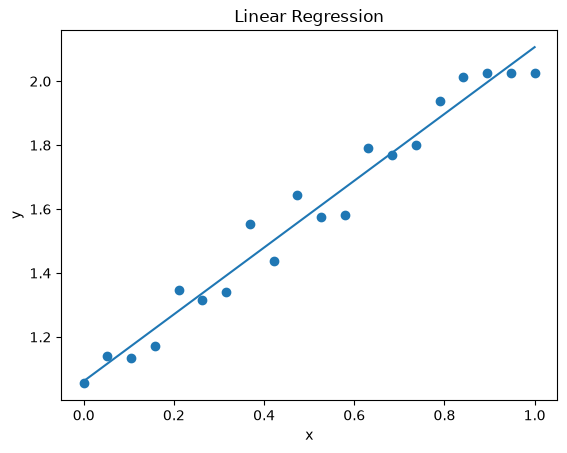

In [120]:
# Draw data and regression
plt.scatter(x, y)       # observed points (with the noise eps)
plt.plot(x, y_pred)     # fitted line

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression")

plt.show()

#### Given a value of x=0.8, predict y value

In [121]:
# Prediction for a value of x that is not in the sample
x_new = 0.8
y_new = beta[0] + beta[1] * x_new   # same formula as before, without building a matrix
print("Predicted y =", y_new)

Predicted y = [1.89764671]


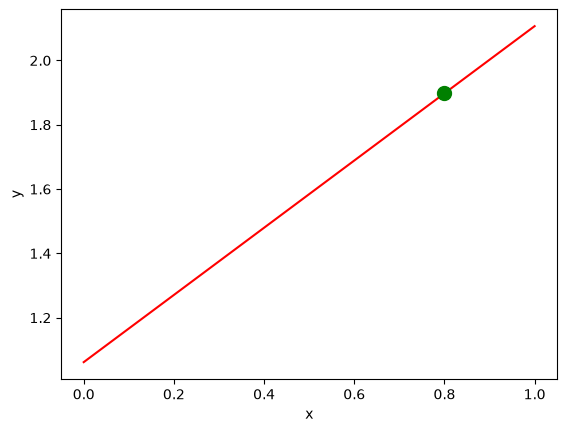

In [122]:
# 0.8 x point with its output y
plt.plot(x, y_pred, 'r')                       # regression line
plt.plot(x_new, y_new, 'go', markersize=10)    # predicted point at x = 0.8

plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Using Sklearn

In [123]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# We already have X in a matrix format
# Note: LinearRegression adds its own intercept, so the ones column is redundant here
# (its coefficient just comes out as 0 and b0 is reported in model.intercept_)
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 2)","[[0. ,1.04]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[1.06]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[1.36,0. ]"


In [124]:
# Same values as the manual beta above
print("b0 =", model.intercept_)   # intercept
print("b1 =", model.coef_)        # [coef of the ones column (~0), slope]

b0 = [1.061775]
b1 = [[0.         1.04483965]]


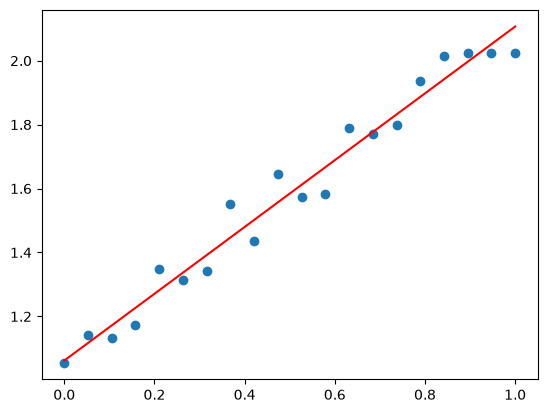

In [125]:
# Check that sklearn's line matches the one we computed by hand
y_line = model.predict(X)
plt.scatter(x, y)
plt.plot(x, y_line, 'r')

In [128]:
# predict() expects a 2D array with the same columns used in fit(), so we rebuild [1, x]
x_new = np.array([[0.8]])
X_new = np.column_stack((np.ones(len(x_new)), x_new))
y_new = model.predict(X_new)
print("Predicted y =", y_new[0])

Predicted y = [1.89764671]
